In [178]:
from __future__ import annotations
from typing import Union
import random
import math

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Optional rustworkx support
try:
    import rustworkx as rx
    RxGraph = rx.PyGraph
except ImportError:
    rx = None
    RxGraph = tuple()

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import Aer
from qiskit import transpile

# CPLEX import
from docplex.mp.model import Model
from quantum_greedy_util import mixer_from_graph
#from classical_heuristics_util import is_vertex_cover, local_search_vertex_cover, ga_vertex_cover
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
import os
import pickle

In [179]:
local = True

# Configuration: change these constants in this file to control runs
# LIMIT: number of graphs to process (None -> all)
# REPS: number of repetitions per parameter set
LIMIT = 20

# If True, treat `LIMIT` as a per-size limit when the script iterates over
# multiple graph sizes (useful when you want N graphs per size). If False,
# LIMIT caps the total number of graphs across all sizes.
LIMIT_PER_SIZE = False

if local:
    # depths 1..4
    settings = [
        {'backend_mode': 'statevector',
         'problem_type': 'minvertexcover',
         'qaoa_variant': 'multiangle_cpm_no_cost_custom',
         'param_initialization': 'uniform',
         'optimizer': 'BFGS',
         'depth': d,
         'warm_start': False}
        for d in range(1, 5)
    ]
    print(' You are running without reading from qaoa_settings.txt - you should never see this message on solstorm!')
#/p/fm/FinleyQuinton/QAOA/QAOA_copy/QAOA_copy/run_my_qaoa/results/graphs/paper_graphs/3_regular/rdr3_20_paper_graphs_n8.pkl
# -------------------- LOAD GRAPHS -------------------- #
#erdos_20_paper_graphs_05P_n20.pkl
#rdr3_20_paper_graphs_n20.pkl
graph_dir = os.path.join(os.path.dirname('erdos_20_paper_graphs_05P_n20.pkl'), "graphs", "erdos")
from glob import glob

# include sizes 8,10,...,14
sizes = [8, 10, 12, 14,16,18,20]
graph_files = []
per_size_counts = {}
for s in sizes:
    pattern = os.path.join(graph_dir, f"*n{s}.pkl")
    found = sorted(glob(pattern))
    if not found:
        # also accept files that contain the size number elsewhere
        found = sorted(glob(os.path.join(graph_dir, f"*{s}*.pkl")))
    # Optionally limit per-size if requested
    if LIMIT is not None and LIMIT_PER_SIZE and found:
        found = found[:LIMIT]
    # record how many pickle files were found for this size (after optional per-size LIMIT)
    per_size_counts[s] = len(found)
    graph_files.extend(found)

if not graph_files:
    raise RuntimeError(f"No graph files found in {graph_dir} for sizes {sizes}")

# Print per-size summary so user can verify how many pickles were found per size
print("[INFO] graph pickle counts per requested size:")
for s in sizes:
    print(f"  n{s}: {per_size_counts.get(s, 0)}")

graph_data = []
for gf in graph_files:
    with open(gf, "rb") as f:
        try:
            data = pickle.load(f)
            if isinstance(data, list):
                graph_data.extend(data)
        except Exception as e:
            print(f"Failed to load {gf}: {e}")

graphs = [g["graph"] if isinstance(g, dict) and "graph" in g else g for g in graph_data]

 You are running without reading from qaoa_settings.txt - you should never see this message on solstorm!
[INFO] graph pickle counts per requested size:
  n8: 1
  n10: 1
  n12: 1
  n14: 1
  n16: 0
  n18: 0
  n20: 1


In [194]:
len(graphs)

100

In [180]:
def rx_to_nx(rx_graph):

    G = nx.Graph()

     # Nodes: indices + data
    for i in rx_graph.node_indices():
        data = rx_graph[i]          # node payload
        G.add_node(i, data=data)

    # Edges: indices + weight/data
    for u, v, w in rx_graph.weighted_edge_list():
        if isinstance(w, dict):
            G.add_edge(u, v, **w)
        else:
            G.add_edge(u, v, weight=w)

    return G

In [181]:
k=-2
G=rx_to_nx(graphs[k]) if rx and isinstance(graphs[k], RxGraph) else graphs[k]

In [182]:
def expectation_value_cost_shifted(qc, betas, C, beta_values, shots=None):
    bind_dict = {betas[i]: beta_values[i] for i in betas}
    qc_bound = qc.assign_parameters(bind_dict)

    n = qc.num_qubits
    paulis = []
    coeffs = []

    for i, c_i in C.items():
        p = ["I"] * n
        p[i] = "Z"
        paulis.append("".join(p))
        coeffs.append(-0.5 * c_i)

    HZ = SparsePauliOp(paulis, coeffs)
    shift = 0.5 * sum(C.values())

    if shots is None:
        psi = Statevector.from_instruction(qc_bound)
        return shift + psi.expectation_value(HZ).real

    # ----- shot-based -----
    qc_meas = qc_bound.copy()
    qc_meas.measure_all()

    backend = Aer.get_backend("aer_simulator")
    qc_meas = transpile(qc_meas, backend)
    counts = backend.run(qc_meas, shots=shots).result().get_counts()

    exp_val = 0.0
    for bitstring, count in counts.items():
        prob = count / shots
        z_vals = np.array([1 if b == "0" else -1 for b in bitstring[::-1]])

        hz_value = 0.0
        for i, c_i in C.items():
            hz_value += -0.5 * c_i * z_vals[i]

        exp_val += prob * hz_value

    return shift + exp_val

In [183]:
def greedy_optimize(qc, betas, C, beta_values,shots=None):
    values = beta_values.copy()
    free = list(betas.keys())
    energies=[]
    while free:
        i = random.choice(free)
        best_val = values[i]
        best_E = expectation_value_cost_shifted(qc, betas, C, values,shots)
        E_aux=[]
        for candidate in (0.0, math.pi/2):
            trial = values.copy()
            trial[i] =  candidate 

            E = expectation_value_cost_shifted(qc, betas, C, trial,shots)
            E_aux.append(E)
            if E < best_E:
                best_E = E
                best_val = candidate
        energies.append(E_aux)
        values[i] = best_val
        free.remove(i)

    return values,energies

def greedy_optimize_seq(qc, betas, C, beta_values,shots= None):
    values = beta_values.copy()

    # assume betas is an ordered mapping or keys are index-like
    indices = list(betas.keys())
    energies=[]
    # iterate from last to first
    for i in reversed(indices):
    #for i in indices:
        best_val = values[i]
        best_E = expectation_value_cost_shifted(qc, betas, C, values,shots)
        E_aux=[]
        for candidate in (0.0, math.pi / 2):
            trial = values.copy()
            trial[i] = candidate
            E = expectation_value_cost_shifted(qc, betas, C, trial,shots)
            E_aux.append(E)
            if E < best_E:
                best_E = E
                best_val = candidate
        energies.append(E_aux)
        values[i] = best_val

    return values,energies

def greedy_optimize_seq_rev(qc, betas, C, beta_values,shots= None):
    values = beta_values.copy()

    # assume betas is an ordered mapping or keys are index-like
    indices = list(betas.keys())
    energies=[]
    # iterate from last to first
    #for i in reversed(indices):
    for i in indices:
        best_val = values[i]
        best_E = expectation_value_cost_shifted(qc, betas, C, values,shots)
        E_aux=[]
        for candidate in (0.0, math.pi / 2):
            trial = values.copy()
            trial[i] = candidate
            E = expectation_value_cost_shifted(qc, betas, C, trial,shots)
            E_aux.append(E)
            if E < best_E:
                best_E = E
                best_val = candidate
        energies.append(E_aux)
        values[i] = best_val

    return values,energies


In [184]:
case="unweighted"
graph_type="regular"
degree=3
shots=1000
seed=None
rng = np.random.default_rng(seed)
graph_seed = rng.integers(1e9)
n=18
n_stat=1
results = {"LP": [], "Dual-Primal": [], "Greedy random edge": [], "Greedy vertex degree": [], "Quantum greedy bias": [], "Quantum greedy seq bias": []}

In [185]:
'''
if graph_type == "erdos":
    p = degree
    G = nx.erdos_renyi_graph(n, p)
elif graph_type == "regular":
    G = nx.random_regular_graph(degree, n)
'''

'\nif graph_type == "erdos":\n    p = degree\n    G = nx.erdos_renyi_graph(n, p)\nelif graph_type == "regular":\n    G = nx.random_regular_graph(degree, n)\n'

In [186]:
import networkx as nx

def plot_graph(G):
    """Plot a NetworkX graph with labels."""
    plt.figure(figsize=(4,4))
    pos = nx.spring_layout(G, seed=42)  # nice-looking layout

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=800,
        node_color="lightblue",
        font_size=12,
        font_weight="bold",
        edge_color="gray"
    )

    plt.title("Graph G")
    plt.axis("off")
    plt.show()

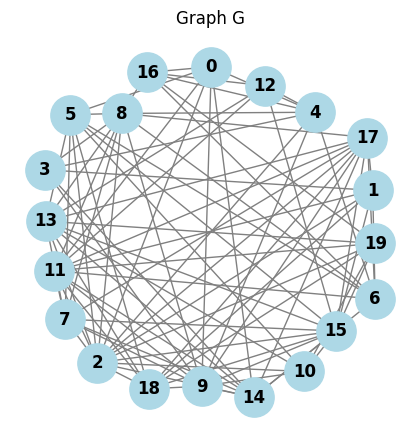

In [187]:
plot_graph(G)

In [188]:
def node_order_by_cost_degree(G, C):
    """
    Order nodes by:
      1) descending cost
      2) descending degree
    """
    return sorted(
        G.nodes(),
        #key=lambda i: (i)
        key=lambda i: (G.degree(i), -C[i]),
        #key=lambda i: (-G.degree(i)/C[i])
    )



# ---------------- Graph & mixer ----------------

def mixer_from_graph(G,c):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    qc = QuantumCircuit(n)
    betas = {i: Parameter(f"β_{i}") for i in G.nodes()}

    for i in range(n):
        qc.x(i)
    # 🔥 ORDER NODES HERE
    ordered_nodes = node_order_by_cost_degree(G,c)
    for tgt in ordered_nodes:
        angle = 2 * betas[tgt]
        ctrls = list(G.neighbors(tgt))
        qc.append(RXGate(angle).control(len(ctrls)), ctrls + [tgt])


    return qc, betas, G


In [189]:
def mean_field_cost_degree_order_init(G, C_cost, order, alpha=1, beta=1, gamma=1,delta=0.2, n_iter=30):
    n = len(G)
    rank = {j: k / n for k, j in enumerate(order)}
    p = {j: 0.5 for j in G.nodes()}
    maxcost= max(C_cost)
    for _ in range(n_iter):
        p_new = {}
        for j in G.nodes():
            dj = max(1, G.degree(j))
            neigh_pressure = sum(p[k] for k in G.neighbors(j)) / dj
            field = (
                alpha * C_cost[j]
                - beta * neigh_pressure
                - gamma * rank[j]
            )
            p_new[j] = 1.0 / (1.0 + np.exp(-delta*field))
        p = p_new

    return {j: np.arcsin(np.sqrt(p[j])) for j in p}


In [190]:

#G = nx.erdos_renyi_graph(n=n, p=degree, seed=int(graph_seed))


if case == "unweighted":
    c = {i: 1.0 for i in G.nodes()}
else:
    c = {i: random.uniform(0.40, 0.70) for i in G.nodes()}

C_opt = mvc_exact_cplex(G, c)
opt_cost = sum(c[i] for i in C_opt)

C_lp = mvc_lp_relaxation(G, c)
results["LP"].append(sum(c[i] for i in C_lp) / opt_cost)

C_pd = mvc_primal_dual_weighted(G,  c)
results["Dual-Primal"].append(sum(c[i] for i in C_pd) / opt_cost)

C_gd = greedy_degree_vertex_cover(G,c)
results["Greedy vertex degree"].append(sum(c[i] for i in C_gd) / opt_cost)
qc, betas, Gn = mixer_from_graph(G,c)
C_cost = {i: c[i] for i in Gn.nodes()}                                          
for s in range(n_stat):
    run_seed = rng.integers(1e9)
    random.seed(int(run_seed))
    np.random.seed(int(run_seed))

    C_ge = greedy_edge_vertex_cover(G,c)
    results["Greedy random edge"].append(sum(c[i] for i in C_ge) / opt_cost)

    

beta_bias1={i: 0.5*np.pi/2 for i in C_cost}
beta_bias4={i: 0.8*np.pi/2 for i in C_cost}

order = node_order_by_cost_degree(G, C_cost)
beta_bias3 = mean_field_cost_degree_order_init(G, order, C_cost, alpha=1,beta=1.0, gamma=1, delta=0.7, n_iter=50)
print("Beta bias 3:", beta_bias3)
print("Beta bias 4:", beta_bias4)


sol_weighted,en1 = greedy_optimize_seq(qc, betas, C_cost, beta_bias3, shots=shots)
E_weighted1 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
sol_weighted,en2 = greedy_optimize_seq(qc, betas, C_cost, beta_bias4, shots=shots)
E_weighted2 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
sol_weighted,en3 = greedy_optimize_seq(qc, betas, C_cost, beta_bias1, shots=shots)
E_weighted3 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
sol_weighted,en4 = greedy_optimize(qc, betas, C_cost, beta_bias1, shots=shots)
E_weighted4 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
sol_weighted,en5 = greedy_optimize(qc, betas, C_cost, beta_bias3, shots=shots)
E_weighted5 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
results["Quantum greedy bias"].append(E_weighted3 / opt_cost)
sol_weighted,en6 = greedy_optimize(qc, betas, C_cost, beta_bias4, shots=shots)
E_weighted6 = expectation_value_cost_shifted(qc, betas, C_cost, sol_weighted, shots=shots)
results["Quantum greedy seq bias"].append(E_weighted4 / opt_cost)

Beta bias 3: {0: np.float64(1.1354449491070366), 1: np.float64(1.5491485034210035), 2: np.float64(1.5287123311535777), 3: np.float64(1.5655697036292406), 4: np.float64(0.5870947218435765), 5: np.float64(0.7489466594912398), 6: np.float64(1.5688671874272333), 7: np.float64(1.2028906606067677), 8: np.float64(1.3821628665523744), 9: np.float64(1.2986482458017807), 10: np.float64(1.4349250632605868), 11: np.float64(1.567720532490262), 12: np.float64(1.5583875391170832), 13: np.float64(1.4669567760885025), 14: np.float64(1.494317568285612), 15: np.float64(1.552009278055701), 16: np.float64(1.5662864530466767), 17: np.float64(1.5304876692964369), 18: np.float64(1.5610255402701783), 19: np.float64(0.7949310813751967)}
Beta bias 4: {0: 1.2566370614359172, 1: 1.2566370614359172, 2: 1.2566370614359172, 3: 1.2566370614359172, 4: 1.2566370614359172, 5: 1.2566370614359172, 6: 1.2566370614359172, 7: 1.2566370614359172, 8: 1.2566370614359172, 9: 1.2566370614359172, 10: 1.2566370614359172, 11: 1.25663

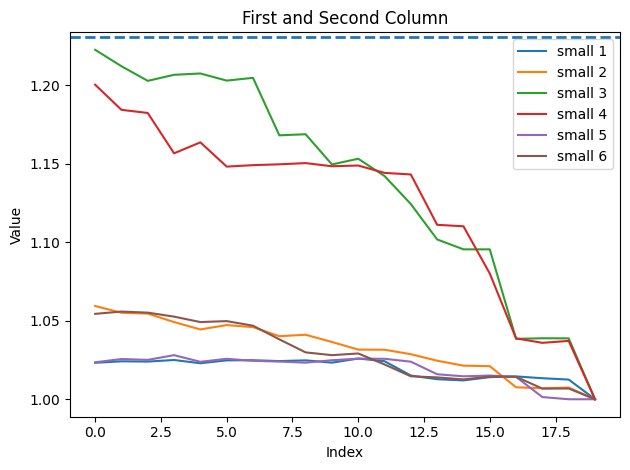

In [191]:
# Convert to NumPy array
data1 = np.array(en1)
data2 = np.array(en2)
data3 = np.array(en3)
data4 = np.array(en4)
data5 = np.array(en5)
data6 = np.array(en6)
# Rearrange each row: [max, min]
rearranged_data1 = np.column_stack((
    np.max(data1, axis=1),
    np.min(data1, axis=1)
))
rearranged_data2 = np.column_stack((
    np.max(data2, axis=1),
    np.min(data2, axis=1)
))
rearranged_data3 = np.column_stack((
    np.max(data3, axis=1),
    np.min(data3, axis=1)
))
rearranged_data4 = np.column_stack((
    np.max(data4, axis=1),
    np.min(data4, axis=1)
))
rearranged_data5 = np.column_stack((
    np.max(data5, axis=1),
    np.min(data5, axis=1)
))
rearranged_data6 = np.column_stack((
    np.max(data6, axis=1),
    np.min(data6, axis=1)
))
# X axis (index)
x = np.arange(len(data1))


# Plot
plt.figure()
#plt.plot(x, rearranged_data1[:, 0]/opt_cost, label="big 1")
plt.plot(x, rearranged_data1[:, 1]/opt_cost, label="small 1")
#plt.plot(x, rearranged_data2[:, 0]/opt_cost, label="big 2")
plt.plot(x, rearranged_data2[:, 1]/opt_cost, label="small 2")
#plt.plot(x, rearranged_data3[:, 0]/opt_cost, label="big 3")
plt.plot(x, rearranged_data3[:, 1]/opt_cost, label="small 3")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data4[:, 1]/opt_cost, label="small 4")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data5[:, 1]/opt_cost, label="small 5")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, rearranged_data6[:, 1]/opt_cost, label="small 6")
plt.axhline(y=results["Greedy vertex degree"][0], linestyle='--', linewidth=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First and Second Column")
plt.legend()
plt.tight_layout()
plt.show()

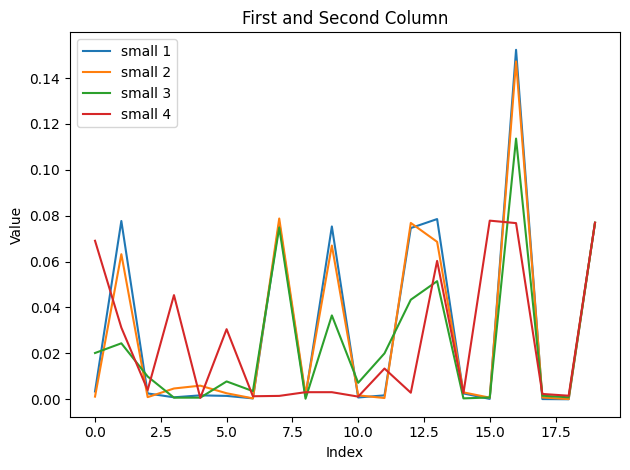

In [192]:
# Plot
plt.figure()
#plt.plot(x, rearranged_data1[:, 0]/opt_cost, label="big 1")
plt.plot(x, -rearranged_data1[:, 1]/opt_cost+rearranged_data1[:, 0]/opt_cost, label="small 1")
#plt.plot(x, rearranged_data2[:, 0]/opt_cost, label="big 2")
plt.plot(x, -rearranged_data2[:, 1]/opt_cost+rearranged_data2[:, 0]/opt_cost, label="small 2")
#plt.plot(x, rearranged_data3[:, 0]/opt_cost, label="big 3")
plt.plot(x, -rearranged_data3[:, 1]/opt_cost+rearranged_data3[:, 0]/opt_cost, label="small 3")
#plt.plot(x, rearranged_data4[:, 0]/opt_cost, label="big 4")
plt.plot(x, -rearranged_data4[:, 1]/opt_cost+rearranged_data4[:, 0]/opt_cost, label="small 4")
#plt.axhline(y=results["Greedy vertex degree"][0], linestyle='--', linewidth=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First and Second Column")
plt.legend()
plt.tight_layout()
plt.show()

In [193]:
results

{'LP': [1.5384615384615385],
 'Dual-Primal': [1.3846153846153846],
 'Greedy random edge': [1.3846153846153846],
 'Greedy vertex degree': [1.2307692307692308],
 'Quantum greedy bias': [np.float64(1.0)],
 'Quantum greedy seq bias': [np.float64(1.0)]}